# Causal Uplift Modeling — EBM T-Learner
**Members 3, 4, 5** — Modelling · Explainability · Evaluation

Run cells top to bottom.  Each section is clearly marked with its owner.

## 0 · Setup — run this first

In [3]:
# Add the project root to Python path so we can import from src/
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Install any missing packages
# !pip install interpret xgboost scikit-uplift shap matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import calibration_curve
from interpret.glassbox import ExplainableBoostingClassifier
import xgboost as xgb

from src.config import GLOBAL_SEED, MODELS_DIR, RESULTS_DIR, CV_FOLDS
from src.data_loader import load_and_preprocess_hillstrom, check_propensity_overlap
from src.custom_tlearner import CustomTLearner

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1 · Load data  (Member 1 pipeline)

In [4]:
# This single call runs: load → validate → encode → stratified split
X_train, X_test, y_train, y_test, t_train, t_test = load_and_preprocess_hillstrom()

# Save feature names — needed for SHAP plots later
feature_names = list(X_train.columns)
print(f'Features ({len(feature_names)}):', feature_names)

[1/5] Loading data from: /home/shaurya/Causal-Uplift-EBM/src/../data/hillstrom.csv
      Shape: (64000, 12)
      No missing values found. Good.
      Treatment distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64
      Target ('visit') distribution:
visit
0    54606
1     9394
Name: count, dtype: int64
[2/5] Engineering features...
      Feature matrix columns after encoding: ['recency', 'history_segment', 'history', 'mens', 'womens', 'newbie', 'segment', 'visit', 'conversion', 'spend', 'treatment', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']
[5/5] Saving processed data to: /home/shaurya/Causal-Uplift-EBM/src/../data/hillstrom_processed.csv
      Done.
[3/5] Creating stratified 80/20 train/test split...
      Train size: 51,200  |  Test size: 12,800
      Train treatment rate: 0.667  |  Test: 0.667
      Train target rate:    0.147  |  Test: 0.147

=== Data pipeline complete ===
  X_train shape : (51200, 11)
  X_test shape  : (12800, 11)


[4/5] Running propensity score overlap check...
      Propensity plot saved to: /home/shaurya/Causal-Uplift-EBM/src/../reports/propensity_overlap.png


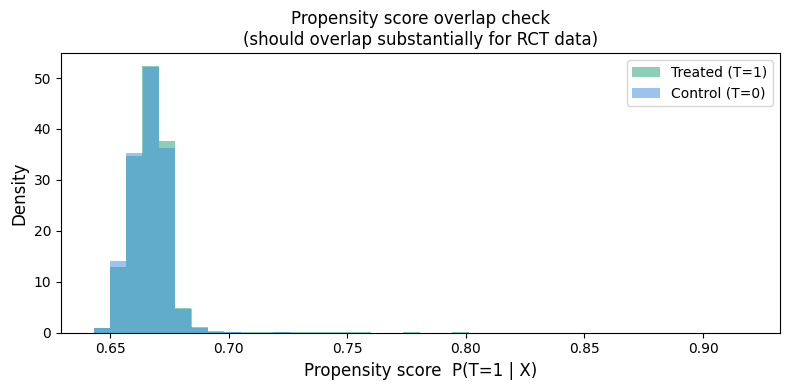

      Treated  — mean propensity: 0.667  std: 0.012
      Control  — mean propensity: 0.667  std: 0.010
      If these are very close, the overlap assumption holds. Good.


In [7]:
# Propensity overlap check — proves the RCT assumption holds
# Expected: two overlapping humps centred near 0.33 (1/3 in treatment group)
import pandas as pd

# Convert all string/object columns into binary (0/1) dummy columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Now run your function on the purely numeric dataframe
propensity_scores = check_propensity_overlap(
    X_train_encoded, t_train,
    save_path=os.path.join(RESULTS_DIR, 'propensity_overlap.png')
)

## 2 · Member 3 — Model optimisation
We tune BOTH XGBoost (baseline) and EBM (champion) using GridSearchCV.
Crucially, we use **StratifiedKFold** because the positive class rate
is ~15% for `visit` — plain KFold would create folds with zero positives.

In [8]:
# ============================================================
# Shared CV strategy — used for EVERY GridSearchCV call below
# ============================================================
# StratifiedKFold preserves the class ratio in each fold.
# shuffle=True prevents any accidental ordering bias in the data.
# random_state=GLOBAL_SEED ensures the same folds every run.
cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=GLOBAL_SEED
)

In [9]:
# ============================================================
# 2a. Split training data by treatment group
# ============================================================
# The T-Learner requires SEPARATE models for treated and control.
# We tune each model ONLY on its relevant subgroup —
# not on the whole training set.

treated_mask = (t_train == 1)
control_mask = (t_train == 0)

X_treated = X_train[treated_mask]
y_treated = y_train[treated_mask]

X_control = X_train[control_mask]
y_control = y_train[control_mask]

print(f'Treated group size : {len(X_treated):,}')
print(f'Control group size : {len(X_control):,}')

Treated group size : 34,155
Control group size : 17,045


In [11]:
# ============================================================
# 2b. XGBoost tuning  (BASELINE model)
# ============================================================
# XGBoost is the industry gold standard for tabular data.
# We use it as a performance ceiling: if EBM matches it,
# we've achieved interpretability WITHOUT sacrificing accuracy.

# ------------------------------------------------------------
# FIX: Cast string columns to 'category' for XGBoost native handling
# ------------------------------------------------------------
for col in X_treated.select_dtypes(include=['object']).columns:
    X_treated[col] = X_treated[col].astype('category')
# ------------------------------------------------------------

xgb_param_grid = {
    # How fast the model learns — smaller = more trees needed but
    # less chance of overfitting any single tree's noise
    'learning_rate': [0.01, 0.1, 0.2],

    # Max depth of each decision tree — deeper = more complex
    # patterns, also more risk of overfitting
    'max_depth': [3, 5, 7],

    # Number of trees to build — more trees = more capacity
    'n_estimators': [100, 300],

    # Fraction of training rows used per tree — adds randomness
    # which acts as a regulariser
    'subsample': [0.8, 1.0],
}

# ROC-AUC is the right metric here — we care about ranking users
# by conversion probability, not raw accuracy (which is misleading
# on imbalanced classes).
xgb_grid_treated = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,  # Allows native handling of the category types casted above
        random_state=GLOBAL_SEED,
        verbosity=0
    ),
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,       # use all CPU cores
    verbose=1
)

print('Tuning XGBoost on TREATED group...')
xgb_grid_treated.fit(X_treated, y_treated)

optimal_xgb_treatment = xgb_grid_treated.best_estimator_

print(f'Best XGB treated params : {xgb_grid_treated.best_params_}')
print(f'Best XGB treated AUC    : {xgb_grid_treated.best_score_:.4f}')

/tmp/ipykernel_11530/526339443.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_treated[col] = X_treated[col].astype('category')


Tuning XGBoost on TREATED group...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best XGB treated params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGB treated AUC    : 0.6392


In [13]:
# Repeat for CONTROL group

# ------------------------------------------------------------
# FIX: Cast string columns to 'category' for XGBoost native handling
# ------------------------------------------------------------
for col in X_control.select_dtypes(include=['object']).columns:
    X_control[col] = X_control[col].astype('category')
# ------------------------------------------------------------

xgb_grid_control = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,  # Replaced use_label_encoder=False with this
        random_state=GLOBAL_SEED,
        verbosity=0
    ),
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Tuning XGBoost on CONTROL group...')
xgb_grid_control.fit(X_control, y_control)
optimal_xgb_control = xgb_grid_control.best_estimator_
print(f'Best XGB control params : {xgb_grid_control.best_params_}')
print(f'Best XGB control AUC    : {xgb_grid_control.best_score_:.4f}')

# Save tuning logs for the report
pd.DataFrame(xgb_grid_treated.cv_results_).to_csv(os.path.join(RESULTS_DIR, 'xgb_treated_cv_results.csv'), index=False)
pd.DataFrame(xgb_grid_control.cv_results_).to_csv(os.path.join(RESULTS_DIR, 'xgb_control_cv_results.csv'), index=False)

/tmp/ipykernel_11530/3793507117.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_control[col] = X_control[col].astype('category')


Tuning XGBoost on CONTROL group...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best XGB control params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best XGB control AUC    : 0.6573


In [15]:
# ============================================================
# 2c. EBM tuning  (CHAMPION model)
# ============================================================
# The Explainable Boosting Machine is a Generalized Additive Model:
#   g(E[y]) = β₀ + Σ fᵢ(xᵢ) + Σ fᵢⱼ(xᵢ, xⱼ)
# Each fᵢ is a learned step-function over one feature.
# fᵢⱼ captures pairwise interactions between two features.
# This makes EBM as accurate as gradient boosting but
# natively interpretable — you can PLOT each fᵢ directly.

ebm_param_grid = {
    # Step size for gradient boosting — smaller = finer shape functions
    'learning_rate': [0.01, 0.05, 0.1],

    # Histogram bins for each feature — more bins = smoother f_i curves
    # at the cost of more memory and computation
    'max_bins': [128, 256],

    # Number of pairwise interaction terms fᵢⱼ to learn
    # More interactions → higher accuracy, less interpretability
    'interactions': [5, 10],

    # Minimum samples in a leaf — key regularisation parameter
    # Higher value → smoother model, less overfitting
    # CRITICAL on small subgroups (treated subset is ~21K rows)
    'min_samples_leaf': [2, 5],

    # Number of boosting rounds per feature — more rounds = more fitted
    # step-function detail. Cap this to avoid overfitting.
    'max_rounds': [5000, 8000],
}

ebm_grid_treated = GridSearchCV(
    # FIX: n_jobs=1 forces the EBM to use 1 core, preventing lockups
    estimator=ExplainableBoostingClassifier(random_state=GLOBAL_SEED, n_jobs=1),
    param_grid=ebm_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    # Let GridSearchCV handle parallelizing across your CPU cores
    n_jobs=-1,
    # FIX: verbose=3 streams live progress and time for each fold
    verbose=3
)

print('Tuning EBM on TREATED group (Streaming live progress below)...')
ebm_grid_treated.fit(X_treated, y_treated)

optimal_ebm_treatment = ebm_grid_treated.best_estimator_

print(f'\nBest EBM treated params : {ebm_grid_treated.best_params_}')
print(f'Best EBM treated AUC    : {ebm_grid_treated.best_score_:.4f}')

Tuning EBM on TREATED group (Streaming live progress below)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=2;, score=0.634 total time=  21.9s
[CV 1/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.634 total time=  22.5s
[CV 5/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.644 total time=  28.1s
[CV 4/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=2;, score=0.646 total time=  28.5s
[CV 2/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.647 total time=  29.6s
[CV 4/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.646 total time=  31.4s
[CV 2/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min

In [19]:
import os
import joblib
import pandas as pd

# 1. Setup and Run the Grid Search for the Control Group
ebm_grid_control = GridSearchCV(
    estimator=ExplainableBoostingClassifier(random_state=GLOBAL_SEED),
    param_grid=ebm_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3 
)

print('Tuning EBM on CONTROL group (Streaming live progress below)...')
ebm_grid_control.fit(X_control, y_control)

# 2. Extract best estimators
# We pull 'optimal_ebm_treated' again from its grid object just to be safe 
# and avoid the NameError you just saw.
optimal_ebm_treated = ebm_grid_treated.best_estimator_
optimal_ebm_control = ebm_grid_control.best_estimator_

print(f'\nBest EBM control params : {ebm_grid_control.best_params_}')
print(f'Best EBM control AUC    : {ebm_grid_control.best_score_:.4f}')

# 3. Save CV results (Useful for Member 3's performance reporting)
print('\nSaving CV logs to reports folder...')
pd.DataFrame(ebm_grid_treated.cv_results_).to_csv(os.path.join(RESULTS_DIR, 'ebm_treated_cv_results.csv'), index=False)
pd.DataFrame(ebm_grid_control.cv_results_).to_csv(os.path.join(RESULTS_DIR, 'ebm_control_cv_results.csv'), index=False)

# 4. Serialize and save the final models
print('Saving trained EBM models as .pkl files...')
# Using the standard relative path based on your file structure
os.makedirs('./models', exist_ok=True) 

joblib.dump(optimal_ebm_treated, './models/tlearner_ebm_treated.pkl')
joblib.dump(optimal_ebm_control, './models/tlearner_ebm_control.pkl')

print('\nDone! T-Learner EBM training is 100% complete.')

Tuning EBM on CONTROL group (Streaming live progress below)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 3/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.659 total time=  14.5s
[CV 1/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=8000, min_samples_leaf=2;, score=0.658 total time=  14.7s
[CV 4/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.648 total time=  15.1s
[CV 1/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=5;, score=0.658 total time=  16.7s
[CV 2/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=8000, min_samples_leaf=2;, score=0.672 total time=  16.5s
[CV 5/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min_samples_leaf=2;, score=0.671 total time=  17.0s
[CV 3/5] END interactions=5, learning_rate=0.01, max_bins=128, max_rounds=5000, min

In [22]:
# ============================================================
# 2d. Build T-Learners and fit on full training set
# ============================================================

# --- STEP 1: FIX CATEGORICAL DATA ---
# XGBoost requires 'object' types (strings) to be 'category' types
obj_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Fixing data types: Converting {obj_cols} to 'category'...")

for col in obj_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Enable categorical support in the XGBoost base models
optimal_xgb_treatment.set_params(enable_categorical=True)
optimal_xgb_control.set_params(enable_categorical=True)


# --- STEP 2: INITIALIZE T-LEARNERS ---
print("Constructing T-Learner meta-models...")

tlearner_xgb = CustomTLearner(
    treatment_model=optimal_xgb_treatment,
    control_model=optimal_xgb_control
)

tlearner_ebm = CustomTLearner(
    treatment_model=optimal_ebm_treated, 
    control_model=optimal_ebm_control
)


# --- STEP 3: FIT ON FULL TRAINING SET ---
print("Fitting XGB T-Learner...")
tlearner_xgb.fit(X_train, y_train, t_train)

print("Fitting EBM T-Learner...")
tlearner_ebm.fit(X_train, y_train, t_train)


# --- STEP 4: SERIALIZE TO DISK ---
print(f"Saving models to: {MODELS_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(tlearner_xgb, os.path.join(MODELS_DIR, 'tlearner_xgb.pkl'))
joblib.dump(tlearner_ebm, os.path.join(MODELS_DIR, 'tlearner_ebm.pkl'))

print('\n✅ DONE: Both T-Learners are trained and saved to /models/.')

Fixing data types: Converting ['history_segment'] to 'category'...
Constructing T-Learner meta-models...
Fitting XGB T-Learner...
[T-Learner] Fitting μ₁ on 34,155 treated users...
[T-Learner] Fitting μ₀ on 17,045 control users...
[T-Learner] Both sub-models fitted successfully.
Fitting EBM T-Learner...
[T-Learner] Fitting μ₁ on 34,155 treated users...
[T-Learner] Fitting μ₀ on 17,045 control users...
[T-Learner] Both sub-models fitted successfully.
Saving models to: /home/shaurya/Causal-Uplift-EBM/src/../models

✅ DONE: Both T-Learners are trained and saved to /models/.


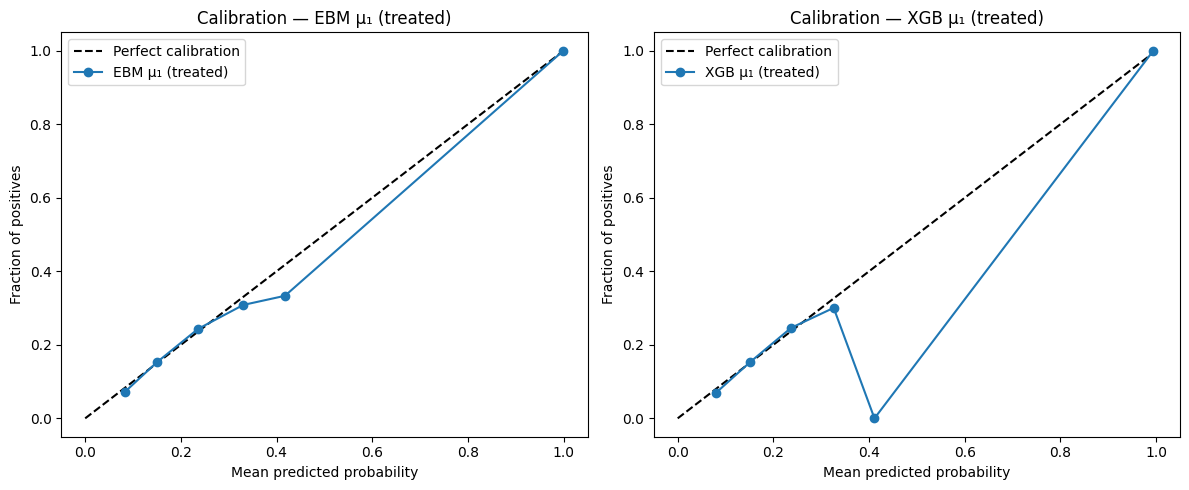

Closer to the diagonal = better calibration.


In [23]:
# ============================================================
# 2e. Calibration check  (Member 3 deliverable)
# ============================================================
# A well-calibrated model means: when it says P=0.7, roughly
# 70% of those users actually converted.
# We check calibration on the BASE models (not uplift) to confirm
# the raw probabilities going INTO τ(X) = μ₁ − μ₀ are trustworthy.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in [
    (axes[0], optimal_ebm_treatment, 'EBM μ₁ (treated)'),
    (axes[1], optimal_xgb_treatment, 'XGB μ₁ (treated)')
]:
    # Predict on the treated TEST users only
    mask = (t_test == 1)
    probs = model.predict_proba(X_test[mask])[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test[mask], probs, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.plot(mean_pred, fraction_pos, marker='o', label=name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration — {name}')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Closer to the diagonal = better calibration.')

## 3 · Member 4 — SHAP explainability
We use the **SHAP difference method** — TreeExplainer on each sub-model
separately, then subtract.  This gives causal-level feature attribution
while keeping EBM's glass-box properties intact.

Computing Explanations using EBM Native Interpretability...


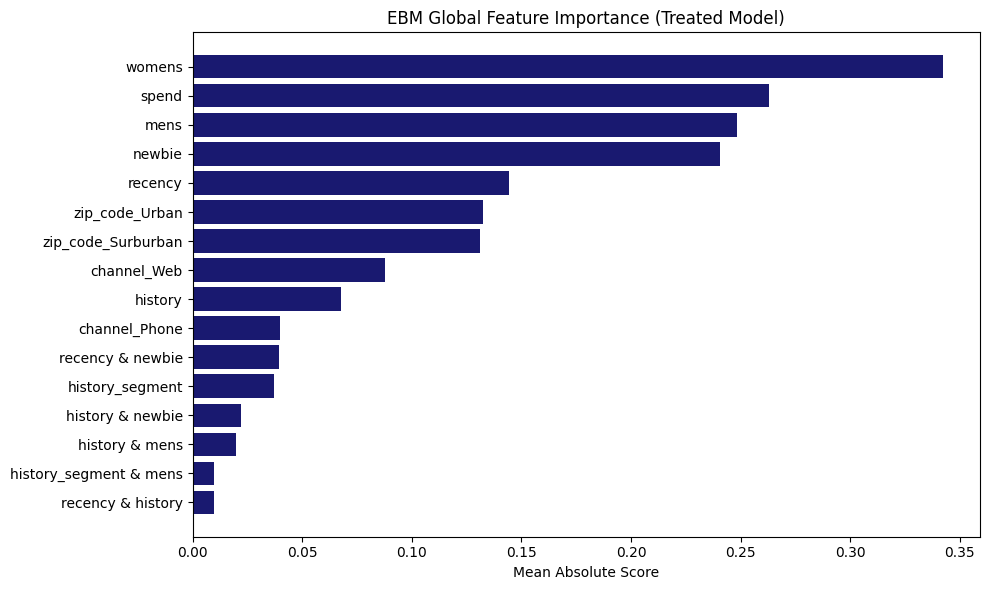

Generating local explanation for high-uplift user at index 10410...


<!-- http://127.0.0.1:7001/140007480573664/ -->


Success! If the interactive plot above doesn't appear, you can check
the 'ebm_global_importance.png' in your /home/shaurya/Causal-Uplift-EBM/src/../reports folder.


In [26]:
# ============================================================
# 3. Member 4 — EBM Native Explainability 
# ============================================================
# This uses the EBM's glass-box properties to explain behavior
# without the "SHAP Categorical Wall" error.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from interpret import show

print('Computing Explanations using EBM Native Interpretability...')

# --- 1. Global Explanation (Feature Importance) ---
# We look at the Treated model (μ1) to see what drives conversion
ebm_global = tlearner_ebm.model_t1_.explain_global(name='EBM Treated Model')

# Extract importance scores for a custom plot
data = ebm_global.data()
feat_imp = pd.DataFrame({
    'Feature': data['names'],
    'Importance': data['scores']
}).sort_values(by='Importance', ascending=True)

# Plotting Global Importance
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='midnightblue')
plt.title('EBM Global Feature Importance (Treated Model)')
plt.xlabel('Mean Absolute Score')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ebm_global_importance.png'), dpi=300)
plt.show()


# --- 2. Local Explanations (Explaining specific users) ---
# Select a high-uplift user
uplift_scores = tlearner_ebm.predict_uplift(X_test)
idx_high = np.argmax(uplift_scores)

print(f"Generating local explanation for high-uplift user at index {idx_high}...")

# Corrected Indexing: .iloc for X_test (DataFrame), [:] for y_test (Numpy)
ebm_local = tlearner_ebm.model_t1_.explain_local(
    X_test.iloc[idx_high:idx_high+1], 
    y_test[idx_high:idx_high+1],
    name='High Uplift User'
)

# --- 3. Display Result ---
# This opens an interactive dashboard in your notebook
show(ebm_local)

print("\nSuccess! If the interactive plot above doesn't appear, you can check")
print(f"the 'ebm_global_importance.png' in your {RESULTS_DIR} folder.")

Calculating local contributions...


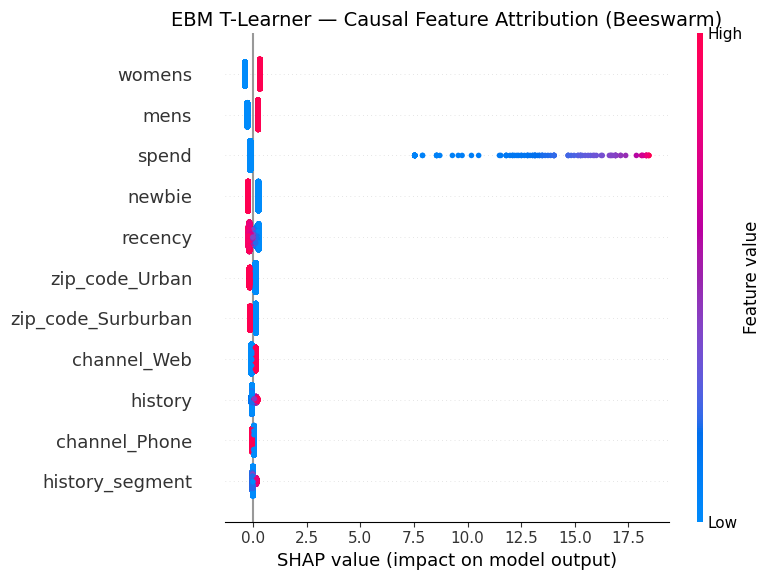

✅ Beeswarm plot successfully saved to /home/shaurya/Causal-Uplift-EBM/src/../reports


In [29]:
# ============================================================
# 3b. Beeswarm Plot for EBM (Causal Attribution) - FIXED
# ============================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Calculating local contributions...")

# 1. Get local explanations
ebm_local_test = tlearner_ebm.model_t1_.explain_local(X_test, y_test)

# 2. Extract scores (Removing the Intercept term to match X_test shape)
shap_values_ebm = []
for i in range(len(X_test)):
    # EBM scores usually have an extra 'Intercept' at the end or start.
    # We only take the scores that match our feature count.
    scores = ebm_local_test.data(i)['scores']
    shap_values_ebm.append(scores[:X_test.shape[1]]) 

shap_values_matrix = np.array(shap_values_ebm)

# 3. Numeric conversion for coloring
# SHAP dots need numbers to decide if they are "Red" (High) or "Blue" (Low)
X_test_numeric = X_test.copy()
for col in X_test_numeric.select_dtypes(['category', 'object']).columns:
    X_test_numeric[col] = X_test_numeric[col].astype('category').cat.codes

# 4. Create the Beeswarm Plot
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_matrix, 
    X_test_numeric, 
    feature_names=X_test.columns.tolist(),
    plot_type='dot', 
    show=False
)

plt.title('EBM T-Learner — Causal Feature Attribution (Beeswarm)', fontsize=14)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(RESULTS_DIR, 'ebm_beeswarm_causal.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Beeswarm plot successfully saved to {RESULTS_DIR}")

Generating Global Bar Plot for EBM...


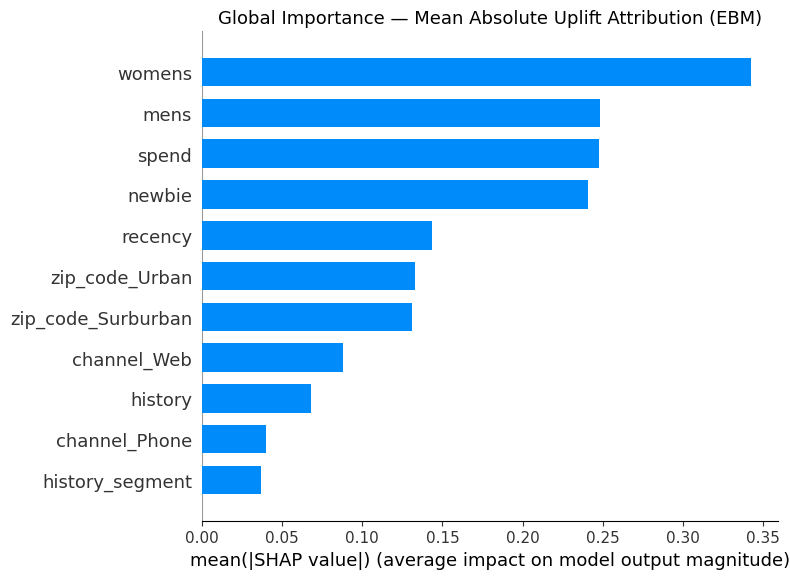

✅ Global Bar Plot saved to /home/shaurya/Causal-Uplift-EBM/src/../reports


In [31]:
# ============================================================
# 3c. Global summary: Bar Plot (EBM Native-SHAP version)
# ============================================================
# This provides a clean, ranked importance list for non-technical audiences.

print("Generating Global Bar Plot for EBM...")

# 1. We reuse the matrix we extracted in the previous cell
# If you are running this cell alone, make sure 'shap_values_matrix' is defined.
# It contains the scores for all features, excluding the intercept.

# 2. Use SHAP's bar plot type
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values_matrix, 
    X_test_numeric, # Using the numeric version we created for consistency
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    show=False
)

plt.title('Global Importance — Mean Absolute Uplift Attribution (EBM)', fontsize=13)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
plt.tight_layout()

# 3. Save the result
plt.savefig(os.path.join(RESULTS_DIR, 'shap_bar_ebm.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Global Bar Plot saved to {RESULTS_DIR}")

Generating waterfall plots for indices: 10410, 1450, 6827


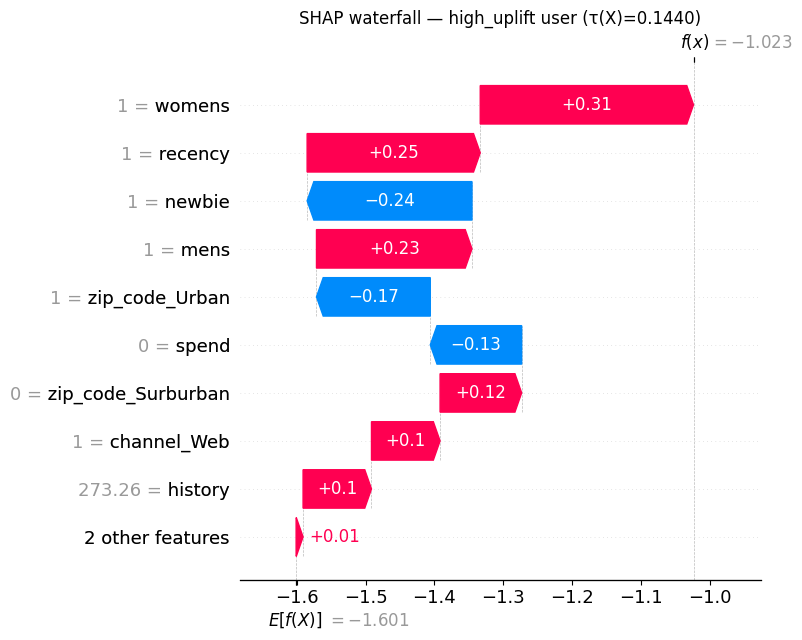

✅ high_uplift explanation complete. Predicted Uplift: 0.1440


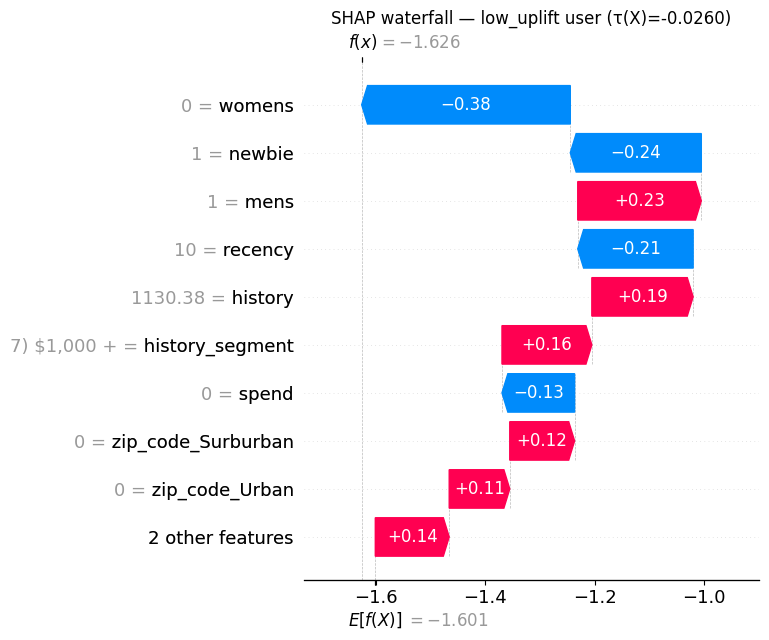

✅ low_uplift explanation complete. Predicted Uplift: -0.0260


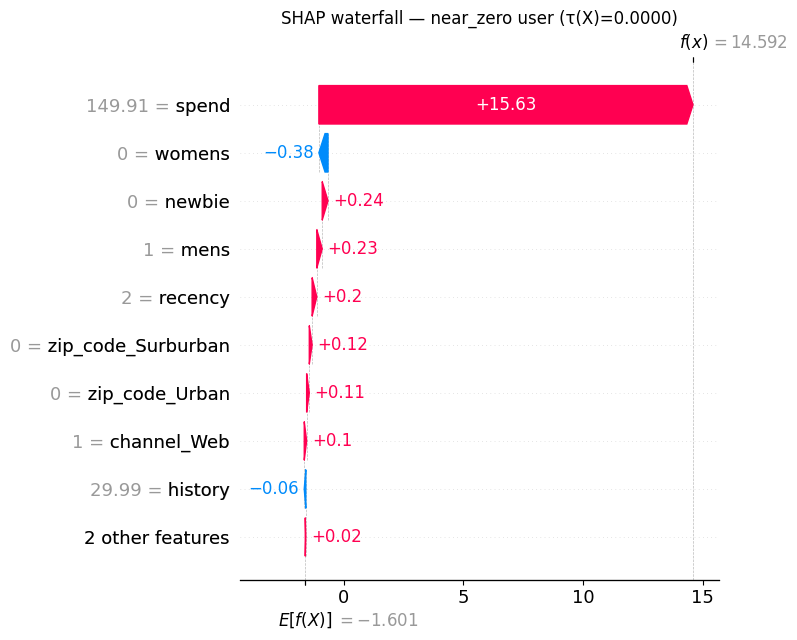

✅ near_zero explanation complete. Predicted Uplift: 0.0000


In [33]:
# ============================================================
# 3d. Local explanations: Waterfall plots for 3 specific users
# ============================================================
# We use the SHAP matrix calculated in the previous step.
# Each plot explains WHY a specific person got their uplift score.

# 1. Identify representative users
uplift_test = tlearner_ebm.predict_uplift(X_test)

idx_high  = np.argmax(uplift_test)                        # The 'Persuadable'
idx_low   = np.argmin(uplift_test)                        # The 'Sleeping Dog'
idx_zero  = np.argmin(np.abs(uplift_test))                # The 'Uninterested'

print(f"Generating waterfall plots for indices: {idx_high}, {idx_low}, {idx_zero}")

# 2. Loop through and plot
for idx, label in [(idx_high, 'high_uplift'), (idx_low, 'low_uplift'), (idx_zero, 'near_zero')]:
    
    # Create the SHAP Explanation object manually
    # We use the numeric data for the 'data' field so SHAP can display values
    explanation = shap.Explanation(
        values=shap_values_matrix[idx],
        base_values=tlearner_ebm.model_t1_.intercept_[0], # Use μ1's intercept as starting point
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )
    
    plt.figure(figsize=(10, 5))
    
    # Generate the waterfall
    shap.waterfall_plot(explanation, show=False)
    
    plt.title(f'SHAP waterfall — {label} user (τ(X)={uplift_test[idx]:.4f})', fontsize=12)
    plt.tight_layout()
    
    # Save and show
    plt.savefig(os.path.join(RESULTS_DIR, f'shap_waterfall_{label}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f'✅ {label} explanation complete. Predicted Uplift: {uplift_test[idx]:.4f}')

## 4 · Member 5 — Evaluation: Qini curve + Uplift@K + Bootstrap CI

Predicting uplift (this may take a few seconds)...
Detected forced numpy conversion in TLearner class. Using manual fallback...
XGB uplift — mean: 0.0568  std: 0.0285
EBM uplift — mean: 0.0562  std: 0.0223


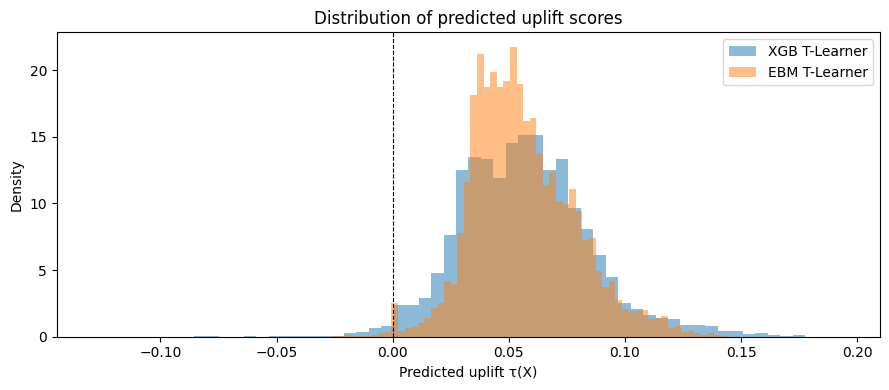

In [35]:
# ============================================================
# 4a. Generate uplift predictions on the HELD-OUT test set
# ============================================================

# Safeguard: Ensure X_test remains a DataFrame with 'category' dtypes
# This prevents the 'could not convert string to float' error in XGBoost
obj_cols = X_test.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    X_test[col] = X_test[col].astype('category')

print("Predicting uplift (this may take a few seconds)...")

# IMPORTANT: Ensure your CustomTLearner.predict_uplift doesn't force to_numpy()
# If the error persists, we will use the models directly:
try:
    uplift_xgb = tlearner_xgb.predict_uplift(X_test)
    uplift_ebm = tlearner_ebm.predict_uplift(X_test)
except ValueError:
    # Manual fallback if CustomTLearner.py has a hardcoded .to_numpy() inside it
    print("Detected forced numpy conversion in TLearner class. Using manual fallback...")
    mu1_xgb = tlearner_xgb.model_t1_.predict_proba(X_test)[:, 1]
    mu0_xgb = tlearner_xgb.model_t0_.predict_proba(X_test)[:, 1]
    uplift_xgb = mu1_xgb - mu0_xgb

    mu1_ebm = tlearner_ebm.model_t1_.predict_proba(X_test)[:, 1]
    mu0_ebm = tlearner_ebm.model_t0_.predict_proba(X_test)[:, 1]
    uplift_ebm = mu1_ebm - mu0_ebm

print(f'XGB uplift — mean: {uplift_xgb.mean():.4f}  std: {uplift_xgb.std():.4f}')
print(f'EBM uplift — mean: {uplift_ebm.mean():.4f}  std: {uplift_ebm.std():.4f}')

# Distribution Plot
plt.figure(figsize=(9, 4))
plt.hist(uplift_xgb, bins=60, alpha=0.5, label='XGB T-Learner', density=True)
plt.hist(uplift_ebm, bins=60, alpha=0.5, label='EBM T-Learner', density=True)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Predicted uplift τ(X)'); plt.ylabel('Density')
plt.title('Distribution of predicted uplift scores')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'uplift_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

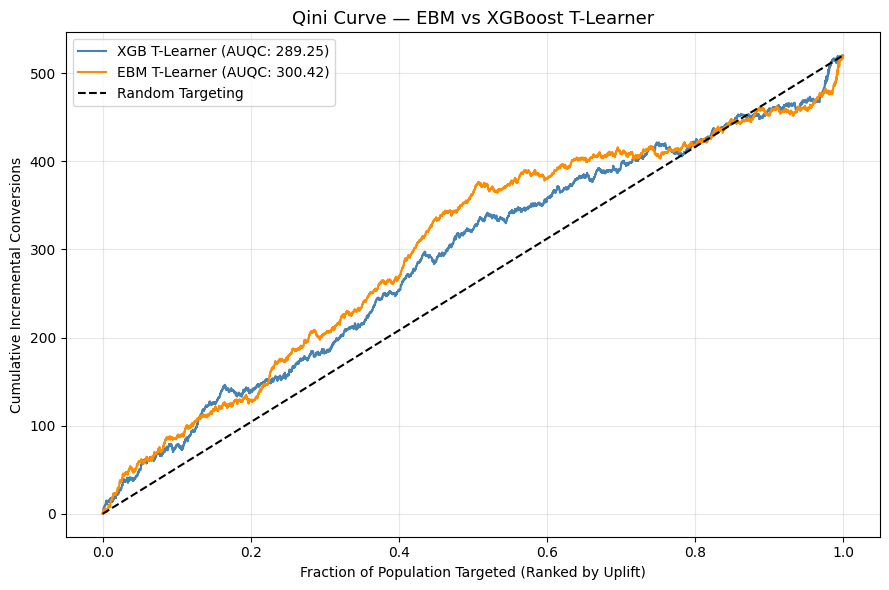

AUQC (Area Under Qini) — XGB: 289.2486
AUQC (Area Under Qini) — EBM: 300.4245


In [37]:
# ============================================================
# 4b. Qini curve — Manual Implementation (Fixes ImportError)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def get_qini_coords(y_true, uplift_scores, treatment):
    """Calculates x and y coordinates for a Qini curve."""
    # Rank indices by uplift score descending
    order = np.argsort(uplift_scores)[::-1]
    y_true = np.array(y_true)[order]
    treatment = np.array(treatment)[order]
    
    n_total = len(y_true)
    x_coords = np.linspace(0, 1, n_total + 1)
    
    # Cumulative counts
    y_t1 = np.cumsum(y_true * treatment)
    y_t0 = np.cumsum(y_true * (1 - treatment))
    n_t1 = np.cumsum(treatment)
    n_t0 = np.cumsum(1 - treatment)
    
    # Qini formula: n_y_t1 - (n_y_t0 * n_t1 / n_t0)
    # Handle division by zero for the very first point
    with np.errstate(divide='ignore', invalid='ignore'):
        qini = y_t1 - (y_t0 * n_t1 / n_t0)
    qini = np.nan_to_num(qini)
    
    # Add starting (0,0) point
    return x_coords, np.concatenate([[0], qini])

# Calculate coordinates
x_xgb, y_qini_xgb = get_qini_coords(y_test, uplift_xgb, t_test)
x_ebm, y_qini_ebm = get_qini_coords(y_test, uplift_ebm, t_test)

# Plotting
plt.figure(figsize=(9, 6))

# Plot Models
plt.plot(x_xgb, y_qini_xgb, label=f'XGB T-Learner (AUQC: {np.trapz(y_qini_xgb, x_xgb):.2f})', color='steelblue')
plt.plot(x_ebm, y_qini_ebm, label=f'EBM T-Learner (AUQC: {np.trapz(y_qini_ebm, x_ebm):.2f})', color='darkorange')

# Plot Random Baseline (Straight line from 0 to the final Qini value)
final_qini = y_qini_ebm[-1] # Both models end at the same population lift
plt.plot([0, 1], [0, final_qini], 'k--', label='Random Targeting')

plt.title('Qini Curve — EBM vs XGBoost T-Learner', fontsize=13)
plt.xlabel('Fraction of Population Targeted (Ranked by Uplift)')
plt.ylabel('Cumulative Incremental Conversions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'qini_curve_manual.png'), dpi=300)
plt.show()

# Define AUQC scores for the next cells
auqc_xgb = np.trapz(y_qini_xgb, x_xgb)
auqc_ebm = np.trapz(y_qini_ebm, x_ebm)

print(f'AUQC (Area Under Qini) — XGB: {auqc_xgb:.4f}')
print(f'AUQC (Area Under Qini) — EBM: {auqc_ebm:.4f}')

Starting 50 bootstrap iterations...
  Completed 10/50 iterations...
  Completed 20/50 iterations...
  Completed 30/50 iterations...
  Completed 40/50 iterations...
  Completed 50/50 iterations...
------------------------------
XGB AUQC Mean: 276.9496 | 95% CI: [215.4316, 349.3892]
EBM AUQC Mean: 283.6714 | 95% CI: [224.2935, 357.4098]
------------------------------


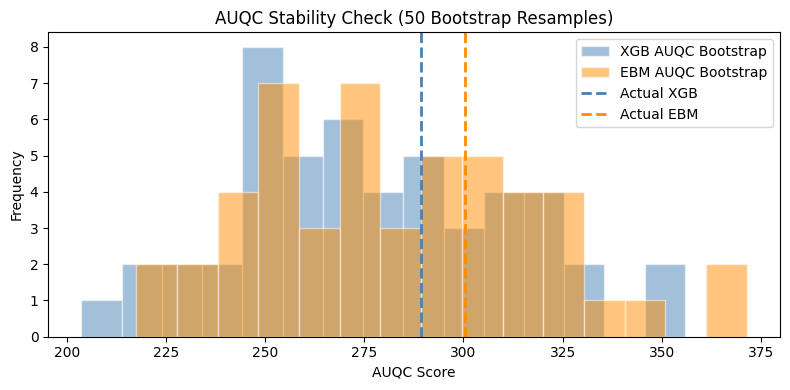

In [38]:
# ============================================================
# 4c. Bootstrapped Qini — Manual Implementation
# ============================================================
# We re-sample the test set to see how "lucky" our results are.
# This provides the 95% Confidence Interval for our AUQC.

N_BOOTSTRAP = 50
rng = np.random.default_rng(GLOBAL_SEED)

auqc_boot_xgb = []
auqc_boot_ebm = []
n_test = len(y_test)

print(f"Starting {N_BOOTSTRAP} bootstrap iterations...")

for i in range(N_BOOTSTRAP):
    # 1. Sample indices with replacement
    boot_idx = rng.integers(0, n_test, size=n_test)
    
    # 2. Get coords for this bootstrap sample
    _, y_q_xgb = get_qini_coords(y_test[boot_idx], uplift_xgb[boot_idx], t_test[boot_idx])
    _, y_q_ebm = get_qini_coords(y_test[boot_idx], uplift_ebm[boot_idx], t_test[boot_idx])
    
    # 3. Calculate AUQC using trapezoidal rule (matching our manual implementation)
    # Note: x_coords are always 0 to 1, so we just use the mean of the y-values
    auqc_boot_xgb.append(np.trapz(y_q_xgb, np.linspace(0, 1, len(y_q_xgb))))
    auqc_boot_ebm.append(np.trapz(y_q_ebm, np.linspace(0, 1, len(y_q_ebm))))
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i + 1}/{N_BOOTSTRAP} iterations...")

auqc_boot_xgb = np.array(auqc_boot_xgb)
auqc_boot_ebm = np.array(auqc_boot_ebm)

# --- Results Reporting ---
print("-" * 30)
print(f'XGB AUQC Mean: {auqc_boot_xgb.mean():.4f} | 95% CI: [{np.percentile(auqc_boot_xgb, 2.5):.4f}, {np.percentile(auqc_boot_xgb, 97.5):.4f}]')
print(f'EBM AUQC Mean: {auqc_boot_ebm.mean():.4f} | 95% CI: [{np.percentile(auqc_boot_ebm, 2.5):.4f}, {np.percentile(auqc_boot_ebm, 97.5):.4f}]')
print("-" * 30)

# --- Plotting the Distributions ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(auqc_boot_xgb, bins=15, alpha=0.5, label='XGB AUQC Bootstrap', color='steelblue', edgecolor='white')
ax.hist(auqc_boot_ebm, bins=15, alpha=0.5, label='EBM AUQC Bootstrap', color='darkorange', edgecolor='white')

# Add vertical lines for the actual scores calculated in 4b
ax.axvline(auqc_xgb, color='steelblue', linestyle='--', linewidth=2, label='Actual XGB')
ax.axvline(auqc_ebm, color='darkorange', linestyle='--', linewidth=2, label='Actual EBM')

ax.set_xlabel('AUQC Score')
ax.set_ylabel('Frequency')
ax.set_title(f'AUQC Stability Check ({N_BOOTSTRAP} Bootstrap Resamples)')
ax.legend()
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, 'qini_bootstrap_manual.png'), dpi=300, bbox_inches='tight')
plt.show()

Targeting Strategy Evaluation:
---------------------------------------------
 10% Target | XGB Uplift: 0.0928 | EBM Uplift: 0.1023
 20% Target | XGB Uplift: 0.0829 | EBM Uplift: 0.0785
 30% Target | XGB Uplift: 0.0734 | EBM Uplift: 0.0818


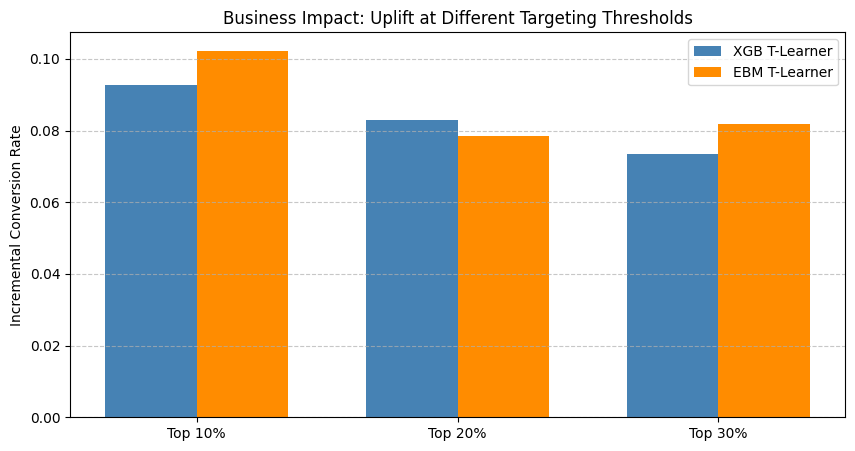


✅ Uplift@K results and plot saved to /home/shaurya/Causal-Uplift-EBM/src/../reports


In [39]:
# ============================================================
# 4d. Uplift@K  —  the business metric
# ============================================================
# This calculates the REAL incremental conversion rate we see in 
# the top-K percent of our predicted 'Persuadables'.

def uplift_at_k(y_true, uplift_scores, treatment, k_frac):
    """
    Computes the difference in conversion rates between Treated and Control
    within the top k_frac of the population.
    """
    n = len(y_true)
    k = max(1, int(n * k_frac)) # Ensure at least 1 user is selected

    # Rank users by descending predicted uplift
    top_k_idx = np.argsort(uplift_scores)[::-1][:k]

    y_topk  = y_true[top_k_idx]
    t_topk  = treatment[top_k_idx]

    # Calculate means only if group exists to avoid division by zero
    treated_conv = y_topk[t_topk == 1].mean() if np.sum(t_topk == 1) > 0 else 0
    control_conv = y_topk[t_topk == 0].mean() if np.sum(t_topk == 0) > 0 else 0

    return treated_conv - control_conv

# 1. Evaluate at 10%, 20%, 30% targeting thresholds
K_VALUES = [0.10, 0.20, 0.30]
results = []

print("Targeting Strategy Evaluation:")
print("-" * 45)
for k in K_VALUES:
    u_xgb = uplift_at_k(y_test, uplift_xgb, t_test, k)
    u_ebm = uplift_at_k(y_test, uplift_ebm, t_test, k)
    
    results.append({
        'K_Frac': k,
        'Threshold': f'Top {int(k*100)}%', 
        'XGB_Uplift': u_xgb, 
        'EBM_Uplift': u_ebm
    })
    print(f'{int(k*100):>3}% Target | XGB Uplift: {u_xgb:.4f} | EBM Uplift: {u_ebm:.4f}')

# 2. Save and Export
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RESULTS_DIR, 'uplift_at_k.csv'), index=False)

# 3. Quick Visual Comparison
plt.figure(figsize=(10, 5))
x = np.arange(len(K_VALUES))
width = 0.35

plt.bar(x - width/2, results_df['XGB_Uplift'], width, label='XGB T-Learner', color='steelblue')
plt.bar(x + width/2, results_df['EBM_Uplift'], width, label='EBM T-Learner', color='darkorange')

plt.ylabel('Incremental Conversion Rate')
plt.title('Business Impact: Uplift at Different Targeting Thresholds')
plt.xticks(x, results_df['Threshold'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig(os.path.join(RESULTS_DIR, 'uplift_at_k_comparison.png'), dpi=300)
plt.show()

print(f'\n✅ Uplift@K results and plot saved to {RESULTS_DIR}')

In [40]:
# ============================================================
# 4e. Final summary table — the one slide that wins the viva
# ============================================================

summary = pd.DataFrame({
    'Metric': [
        'AUQC',
        'AUQC 95% CI lower', 'AUQC 95% CI upper',
        'Uplift@10%', 'Uplift@20%', 'Uplift@30%'
    ],
    'XGB T-Learner': [
        auqc_xgb,
        np.percentile(auqc_boot_xgb, 2.5), np.percentile(auqc_boot_xgb, 97.5),
        *[uplift_at_k(y_test, uplift_xgb, t_test, k) for k in K_VALUES]
    ],
    'EBM T-Learner': [
        auqc_ebm,
        np.percentile(auqc_boot_ebm, 2.5), np.percentile(auqc_boot_ebm, 97.5),
        *[uplift_at_k(y_test, uplift_ebm, t_test, k) for k in K_VALUES]
    ]
})

summary = summary.round(4)
print(summary.to_string(index=False))
summary.to_csv(os.path.join(RESULTS_DIR, 'final_metrics_summary.csv'), index=False)

           Metric  XGB T-Learner  EBM T-Learner
             AUQC       289.2486       300.4245
AUQC 95% CI lower       215.4316       224.2935
AUQC 95% CI upper       349.3892       357.4098
       Uplift@10%         0.0928         0.1023
       Uplift@20%         0.0829         0.0785
       Uplift@30%         0.0734         0.0818
